importing libery


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Data set Download

In [2]:
!wget https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/master/7_nn_from_scratch/insurance_data.csv

--2026-04-20 10:15:01--  https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/master/7_nn_from_scratch/insurance_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231 [text/plain]
Saving to: ‘insurance_data.csv’

insurance_data.csv  100%[===================>]     231  --.-KB/s    in 0s      

2026-04-20 10:15:02 (14.8 MB/s) - ‘insurance_data.csv’ saved [231/231]



In [3]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               28 non-null     int64
 1   affordibility     28 non-null     int64
 2   bought_insurance  28 non-null     int64
dtypes: int64(3)
memory usage: 804.0 bytes


In [11]:
df['age']=df['age']/df['age'].max()

In [25]:
X = df.drop('bought_insurance', axis=1).values
y = df['bought_insurance'].values

Sigmoid activation function

$\sigma(x) = \frac{1}{1 + e^{-x}}$

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Standar Deviation

$SDT = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

In [14]:
def standardize(x):
  return (x - x.mean()) / x.std()

Log Loss Function

$L = - \frac{1}{n} \sum_{i=1}^{n}\left[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \right]$

In [15]:
def Log_loss(y_test,y_predicted):
  epsilon=1e-15
  y_predicted_new = np.maximum(y_predicted,epsilon)
  y_predicted_new = np.minimum(y_predicted_new,1-epsilon)
  return -np.mean(y_test*np.log(y_predicted_new)+(1-y_test)*np.log(1-y_predicted_new))

Bach Gradient descent function

$w = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)x_i$


$b = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$

$wight =wight + w*learing  rate$

$bias= b*learing  rate$

In [37]:
def gradient_descent(X, y, epochs=1000, lr=0.1):

    X = standardize(X)
    n_samples, n_features = X.shape

    # Initialize
    weights = np.zeros(n_features)
    bias = 0

    losses = []
    accuracies = []

    for i in range(epochs):

        # Forward pass
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        # Compute gradients
        error = y_pred - y
        dw = (1 / n_samples) * np.dot(X.T, error)
        db = (1 / n_samples) * np.sum(error)

        # Update parameters
        weights -= lr * dw
        bias -= lr * db

        # Metrics
        loss = Log_loss(y, y_pred)
        predictions = (y_pred > 0.5).astype(int)
        accuracy = np.mean(predictions == y)

        losses.append(loss)
        accuracies.append(accuracy)

        if i % 10 == 0:
            print(f"Epoch {i} | Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

    return weights, bias, losses, accuracies

In [38]:
weights, bias, losses, accuracies = gradient_descent(X, y, epochs=200, lr=0.1)

Epoch 0 | Loss: 0.6931 | Accuracy: 0.5000
Epoch 10 | Loss: 0.6080 | Accuracy: 0.7857
Epoch 20 | Loss: 0.5565 | Accuracy: 0.8571
Epoch 30 | Loss: 0.5217 | Accuracy: 0.8571
Epoch 40 | Loss: 0.4960 | Accuracy: 0.8571
Epoch 50 | Loss: 0.4760 | Accuracy: 0.8929
Epoch 60 | Loss: 0.4599 | Accuracy: 0.8929
Epoch 70 | Loss: 0.4465 | Accuracy: 0.8929
Epoch 80 | Loss: 0.4354 | Accuracy: 0.8929
Epoch 90 | Loss: 0.4259 | Accuracy: 0.9286
Epoch 100 | Loss: 0.4178 | Accuracy: 0.9286
Epoch 110 | Loss: 0.4108 | Accuracy: 0.9286
Epoch 120 | Loss: 0.4048 | Accuracy: 0.9286
Epoch 130 | Loss: 0.3996 | Accuracy: 0.9286
Epoch 140 | Loss: 0.3950 | Accuracy: 0.9286
Epoch 150 | Loss: 0.3910 | Accuracy: 0.9286
Epoch 160 | Loss: 0.3875 | Accuracy: 0.9286
Epoch 170 | Loss: 0.3844 | Accuracy: 0.8929
Epoch 180 | Loss: 0.3817 | Accuracy: 0.8929
Epoch 190 | Loss: 0.3792 | Accuracy: 0.8929


Plot

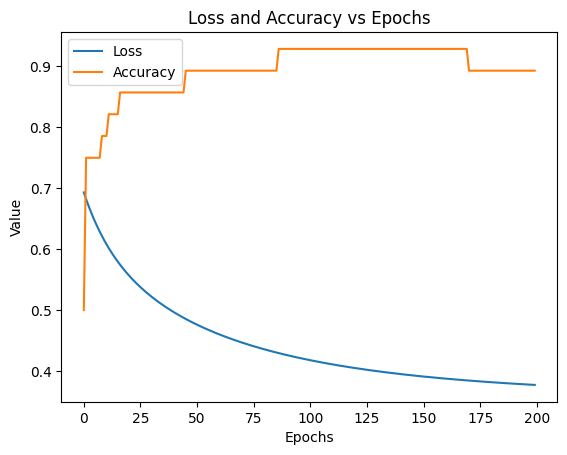

In [39]:
plt.figure()
plt.plot(losses, label='Loss')
plt.plot(accuracies, label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Loss and Accuracy vs Epochs')
plt.legend()
plt.show()